# Homework 2 — Interval Analysis

NUMA01 VT2026 · Arvid Brenner & Sixten Midsem

In [1]:
import numpy as np                              # numpy som np
from numpy import linspace                       # bara linspace räcker
import matplotlib.pyplot as plt                  # plottning

%matplotlib inline

## Klassen `Interval`

In [ ]:
class Interval:
    """Slutet reellt intervall [a, b] med +, -, *, /, **, in och enställig minus."""

    # --- Task 1 + Task 7 ---
    def __init__(self, a, b=None):
        # spara vänsterändpunkten
        self.a = a
        # om bara ett tal getts (Task 7) sätter vi höger = vänster -> [a, a]
        # (vi använder b=None som default eftersom default-värden i Python
        # binds vid funktionens definition, inte vid varje anrop, så a är
        # inte tillgängligt som default för b)
        self.b = a if b is None else b

    # --- Task 3 ---
    def __repr__(self):
        # styr hur intervallet skrivs ut med print()
        return f"[{self.a}, {self.b}]"

    # --- Task 2 (utökad i Task 8 för skalärer) ---
    def __add__(self, other):
        # om andra operanden är ett vanligt tal, gör om det till [r, r]
        if isinstance(other, (int, float)):
            other = type(self)(other)
        # vänster + vänster blir nytt vänster, höger + höger blir nytt höger
        return type(self)(self.a + other.a, self.b + other.b)

    def __sub__(self, other):
        # samma promotion av skalär som i __add__
        if isinstance(other, (int, float)):
            other = type(self)(other)
        # nytt vänster = a - d, nytt höger = b - c
        # (vi tar vänster minus största möjliga höger, och tvärtom)
        return type(self)(self.a - other.b, self.b - other.a)

    def __mul__(self, other):
        if isinstance(other, (int, float)):
            other = type(self)(other)
        # plocka ut ändpunkterna för båda intervallen
        a, b, c, d = self.a, self.b, other.a, other.b
        # multiplikationens min och max ligger alltid i något av de fyra hörnen
        # av rektangeln [a,b] x [c,d], så vi räknar alla fyra och tar min/max
        hörn = (a * c, a * d, b * c, b * d)
        return type(self)(min(hörn), max(hörn))

    def __truediv__(self, other):
        if isinstance(other, (int, float)):
            other = type(self)(other)
        a, b, c, d = self.a, self.b, other.a, other.b
        # Task 6: om 0 ligger i nämnaren är resultatet odefinierat eller
        # obegränsat — vi kastar ZeroDivisionError, samma typ som Python
        # själv kastar för 1/0, så vanlig try/except fångar fallet
        if c <= 0 <= d:
            raise ZeroDivisionError(
                f"Nämnarintervallet [{c}, {d}] innehåller 0 — division odefinierad."
            )
        # samma hörn-trick som för multiplikation
        hörn = (a / c, a / d, b / c, b / d)
        return type(self)(min(hörn), max(hörn))

    # --- Task 8: höger-versioner (tal till vänster om intervall) ---
    def __radd__(self, other):
        # 1 + I -> Python anropar I.__radd__(1). Addition är kommutativ
        # så vi skickar tillbaka till __add__ med vänd ordning.
        return self + other

    def __rsub__(self, other):
        # 1 - I är INTE samma som I - 1, så vi promotar och vänder ordningen
        return type(self)(other) - self

    def __rmul__(self, other):
        # multiplikation är kommutativ -> återanvänd __mul__
        return self * other

    def __neg__(self):
        # -[a, b] = [-b, -a] — ändpunkterna byter plats så att vänster ≤ höger
        return type(self)(-self.b, -self.a)

    # --- Task 5 ---
    def __contains__(self, x):
        # Pythons kedjade jämförelse -> True om a <= x <= b (ändpunkter ingår)
        return self.a <= x <= self.b

    # --- Task 9 ---
    def __pow__(self, n):
        # uppgiften kräver n >= 1 (positivt heltal). Vi kollar tidigt så att
        # I**0.5 eller I**-1 ger ett begripligt fel
        if not isinstance(n, int) or n < 1:
            raise ValueError("Endast positiva heltalspotenser (n >= 1) stöds.")
        a, b = self.a, self.b
        # udda n -> x^n är monotont stigande, ändpunkterna mappas direkt
        if n % 2 == 1:
            return type(self)(a**n, b**n)
        # jämn n -> tre fall beroende på var intervallet ligger relativt 0
        if a >= 0:
            # hela intervallet är icke-negativt -> x^n stigande här också
            return type(self)(a**n, b**n)
        if b < 0:
            # hela intervallet är negativt -> x^n avtagande, vänd ändpunkterna
            return type(self)(b**n, a**n)
        # intervallet korsar 0 -> minsta värdet är 0 (vid x = 0),
        # största är det större av a^n och b^n
        return type(self)(0, max(a**n, b**n))

## Task 1 + Task 7 — konstruktor

In [3]:
# två-arg-konstruktorn (Task 1)
I = Interval(1, 4)
print("a =", I.a)                              # 1
print("b =", I.b)                              # 4

# ett-arg-konstruktorn (Task 7) -> degenererat intervall [r, r]
print("Interval(3) =", Interval(3))            # [3, 3]
print("Interval(3.14) =", Interval(3.14))      # [3.14, 3.14]

a = 1
b = 4
Interval(3) = [3, 3]
Interval(3.14) = [3.14, 3.14]


## Task 3 + Task 4 — utskrift och räknesätt

In [4]:
# Task 3: __repr__ ger utskriftformatet [a, b]
print(Interval(1, 2))                          # [1, 2]

# Task 4: kör exakt uttrycken från uppgiften, jämför med kommenterade värden
I1 = Interval(1, 4)                            # [1, 4]
I2 = Interval(-2, -1)                          # [-2, -1]
print("I1 + I2 =", I1 + I2)                    # [-1, 3]
print("I1 - I2 =", I1 - I2)                    # [2, 6]
print("I1 * I2 =", I1 * I2)                    # [-8, -1]
print("I1 / I2 =", I1 / I2)                    # [-4.0, -0.5]

[1, 2]
I1 + I2 = [-1, 3]
I1 - I2 = [2, 6]
I1 * I2 = [-8, -1]
I1 / I2 = [-4.0, -0.5]


## Task 5 — medlemskap

In [5]:
I = Interval(1, 4)
print("2.5 in I  ->", 2.5 in I)                # True (ligger mellan)
print("5   in I  ->", 5 in I)                  # False (utanför)
print("1   in I  ->", 1 in I)                  # True (vänsterändpunkten ingår)
print("4   in I  ->", 4 in I)                  # True (högerändpunkten ingår)

2.5 in I  -> True
5   in I  -> False
1   in I  -> True
4   in I  -> True


## Task 6 — division med 0 i nämnaren

In [6]:
# fel-fall: nämnaren innehåller 0 -> ZeroDivisionError ska kastas
try:
    bad = Interval(1, 2) / Interval(-1, 1)
    print("oväntat inget fel:", bad)
except ZeroDivisionError as e:
    print("fångade ZeroDivisionError:", e)

# OK-fall: nämnaren undviker 0 -> vanlig division fungerar
print("OK:", Interval(1, 4) / Interval(-2, -1))   # [-4.0, -0.5]

fångade ZeroDivisionError: Nämnarintervallet [-1, 1] innehåller 0 — division odefinierad.
OK: [-4.0, -0.5]


## Task 8 — intervall + skalärer (åt båda håll)

In [7]:
# de 13 uttrycken uppgiften listar, med förväntade värden i kommentarerna
print("Interval(2, 3) + 1   =", Interval(2, 3) + 1)     # [3, 4]
print("1 + Interval(2, 3)   =", 1 + Interval(2, 3))     # [3, 4]
print("1.0 + Interval(2, 3) =", 1.0 + Interval(2, 3))   # [3.0, 4.0]
print("Interval(2, 3) + 1.0 =", Interval(2, 3) + 1.0)   # [3.0, 4.0]
print("1 - Interval(2, 3)   =", 1 - Interval(2, 3))     # [-2, -1]
print("Interval(2, 3) - 1   =", Interval(2, 3) - 1)     # [1, 2]
print("1.0 - Interval(2, 3) =", 1.0 - Interval(2, 3))   # [-2.0, -1.0]
print("Interval(2, 3) - 1.0 =", Interval(2, 3) - 1.0)   # [1.0, 2.0]
print("Interval(2, 3) * 1   =", Interval(2, 3) * 1)     # [2, 3]
print("1 * Interval(2, 3)   =", 1 * Interval(2, 3))     # [2, 3]
print("1.0 * Interval(2, 3) =", 1.0 * Interval(2, 3))   # [2.0, 3.0]
print("Interval(2, 3) * 1.0 =", Interval(2, 3) * 1.0)   # [2.0, 3.0]
print("-Interval(4, 5)      =", -Interval(4, 5))        # [-5, -4]

Interval(2, 3) + 1   = [3, 4]
1 + Interval(2, 3)   = [3, 4]
1.0 + Interval(2, 3) = [3.0, 4.0]
Interval(2, 3) + 1.0 = [3.0, 4.0]
1 - Interval(2, 3)   = [-2, -1]
Interval(2, 3) - 1   = [1, 2]
1.0 - Interval(2, 3) = [-2.0, -1.0]
Interval(2, 3) - 1.0 = [1.0, 2.0]
Interval(2, 3) * 1   = [2, 3]
1 * Interval(2, 3)   = [2, 3]
1.0 * Interval(2, 3) = [2.0, 3.0]
Interval(2, 3) * 1.0 = [2.0, 3.0]
-Interval(4, 5)      = [-5, -4]


## Task 9 — potens

In [8]:
x = Interval(-2, 2)
print("x      =", x)                                       # [-2, 2]
print("x ** 2 =", x ** 2)                                  # [0, 4]   (jämn n, korsar 0)
print("x ** 3 =", x ** 3)                                  # [-8, 8]  (udda n)

# verifiera de andra jämn-fallen också
print("Interval(1, 3)   ** 2 =", Interval(1, 3) ** 2)      # a >= 0 -> [1, 9]
print("Interval(-3, -1) ** 2 =", Interval(-3, -1) ** 2)    # b < 0  -> [1, 9]

x      = [-2, 2]
x ** 2 = [0, 4]
x ** 3 = [-8, 8]
Interval(1, 3)   ** 2 = [1, 9]
Interval(-3, -1) ** 2 = [1, 9]


## Task 10 — polynom på 1000 intervall

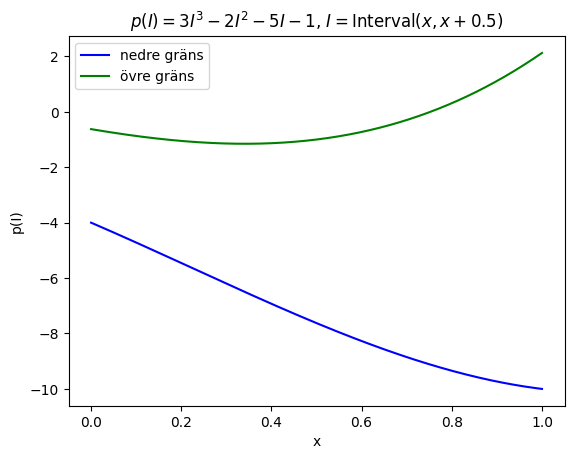

In [9]:
xl = linspace(0., 1, 1000)                          # 1000 vänsterändpunkter mellan 0 och 1
xu = xl + 0.5                                       # högerändpunkter förskjutna 0.5 åt höger

# bygg listan av intervall genom att pair-zip:a vänster- och högerändpunkter
intervaller = [Interval(l, u) for l, u in zip(xl, xu)]


def p(I):
    """p(I) = 3I^3 - 2I^2 - 5I - 1."""
    # __pow__ används för I^3 och I^2 (inte I*I*I), för att intervallpotens
    # ger ett smalare och rätt resultat — multiplikation behandlar de två
    # faktorerna som oberoende och blåser upp intervallet
    return 3 * I**3 - 2 * I**2 - 5 * I - 1


# evaluera polynomet på varje intervall -> lista av resulterande intervall
resultat = [p(I) for I in intervaller]

# plocka ut undre och övre gränserna ur varje resultatintervall
yl = [r.a for r in resultat]
yu = [r.b for r in resultat]

# rita upp båda kurvorna mot x, blå undre och grön övre som uppgiftsbilden visar
plt.plot(xl, yl, "b", label="nedre gräns")
plt.plot(xl, yu, "g", label="övre gräns")
plt.title(r"$p(I) = 3I^3 - 2I^2 - 5I - 1$, $I = $Interval$(x, x + 0.5)$")
plt.xlabel("x")
plt.ylabel("p(I)")
plt.legend()
plt.show()